Setup

In [1]:
!pip install scikit-optimize

In [2]:
%pip install numpy
%pip install matplotlib
%pip install tensorboard
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg

jlPkg.activate(".")
jl.include("models/model_host_cutoff.jl")
#jlPkg.instantiate() #run the first time using this repo

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Coding/RL clean copy`


  0.542977 seconds (2.22 M allocations: 124.282 MiB, 3.39% gc time, 99.58% compilation time)
  2.175204 seconds (52.76 M allocations: 6.042 GiB, 10.73% gc time, 1.38% compilation time)


experession_and_growth (generic function with 1 method)

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

class Regressor(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# Initialize the model first (the same architecture as before)
model_load = Regressor(input_dim=4, hidden_dim=32)

# Load the state_dict into the model
model_load.load_state_dict(torch.load("regressor_model.pth"))

model_load.eval()

/var/folders/g5/zfzq1xm948s47p2wdqk_5ql00000gn/T/ipykernel_74892/2586044101.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_load.load_state_dict(torch.load("regre

Regressor(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [4]:
xx = np.hstack([[0.521213795535383,
 0.5868067574533484,
 0.8908786980927811], [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log
y_pred_log

/var/folders/g5/zfzq1xm948s47p2wdqk_5ql00000gn/T/ipykernel_74892/1540414533.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  x_t = torch.tensor([xx], dtype=torch.float32)


array(3.727303, dtype=float32)

In [178]:
import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding
from stable_baselines3 import PPO

# ==== Configuration ====
log_dir = "logs/rl_host_cutoff"


In [179]:
unc = np.random.rand(3)

In [180]:
np.exp(10)

22026.465794806718

In [194]:
jl.experession_and_growth(unc,np.exp(10))

(6.518382554154225, 0.581585597551271)

In [195]:
xx = np.hstack([unc, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10
y_pred

0.8478741645812988

In [196]:
np.exp(y_pred*10)

4811.391651131005

In [213]:
jl.experession_and_growth(unc,np.exp(y_pred*10)) + np.random.rand(2)*(0.1,0.05)

array([3.84626126, 0.83705074])

In [214]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding

# assume the Julia interface is already loaded as jl
# from juliacall import Main as jl

class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        # ===== Environment dimensions =====
        self.obs_dim = 2           # observation 
        self.action_dim = 1        # action = scalar in [-1, 1]
        self.uncertain_dim = 3     # hidden state (e.g., uncertain parameters)
        self.n_steps = max_episode_steps

        # ===== Spaces =====
        # same structure as before: (1, n_steps * (obs_dim + action_dim))
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32,
        )

        # ===== State variables =====
        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)
        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)

    # -------------------------------------
    #  Seeding
    # -------------------------------------
    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]

    # -------------------------------------
    #  Reset
    # -------------------------------------
    def reset(self, seed=None, options=None):
        if options is not None and "uncertain" in options:
            self.uncertain = np.array(options["uncertain"], dtype=np.float32)
        else:
            self.uncertain = np.random.rand(self.uncertain_dim).astype(np.float32)

        if seed is not None:
            self.seed(seed)

        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    # -------------------------------------
    #  Step
    # -------------------------------------
    def step(self, action):
        # ensure correct shape
        action = np.clip(action, -1, 1).astype(np.float32)
        action_scalar = float(action[0])

        # compute reward (observation) from Julia
        obs_vector = np.array(jl.experession_and_growth(self.uncertain,np.exp(action_scalar*10))) + np.random.rand(2)*(0.1,0.05)

        
        xx = np.hstack([self.uncertain, [0.8]])
        x_t = torch.tensor([xx], dtype=torch.float32)
        with torch.no_grad():
            y_pred_log = model_load(x_t).numpy().squeeze()
            y_pred = y_pred_log/10

        # fill in the effective observation buffer
        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        # increment
        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), -np.abs(y_pred-action.item()), terminated, truncated, info


Training

In [215]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
# Running this cell will overide any existing monitors
log_dir = "logs/rl_host_cutoff/"
os.makedirs(log_dir, exist_ok=True)

# =============================== #
# ✅ Monitor environment for logging
# =============================== #

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")  # your Julia seed
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

model = PPO(
    "MlpPolicy", 
    env,
    verbose=1,
    tensorboard_log=log_dir,   # Optional: enables TensorBoard
    seed=SEED,
    learning_rate=3e-4,
    clip_range=0.01,

)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [217]:
# Train the model
model.learn(total_timesteps=2_000_000)
# runtime 51min 44s

# Save the model
model.save(os.path.join(log_dir, "ppo_model"))

Logging to logs/rl_host_cutoff/PPO_20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | -1.92    |
| time/              |          |
|    fps             | 153      |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 5            |
|    ep_rew_mean          | -1.92        |
| time/                   |              |
|    fps                  | 150          |
|    iterations           | 2            |
|    time_elapsed         | 27           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 7.511664e-05 |
|    clip_fraction        | 0.173        |
|    clip_range           | 0.01         |
|    entropy_loss         | -1.41        |
|    explained_varia

In [173]:
model.save(os.path.join(log_dir, "ppo_model"))

Evaluation

In [18]:
model.save(os.path.join(log_dir, "ppo_model"))

In [218]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

model = PPO.load(model_path)


df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


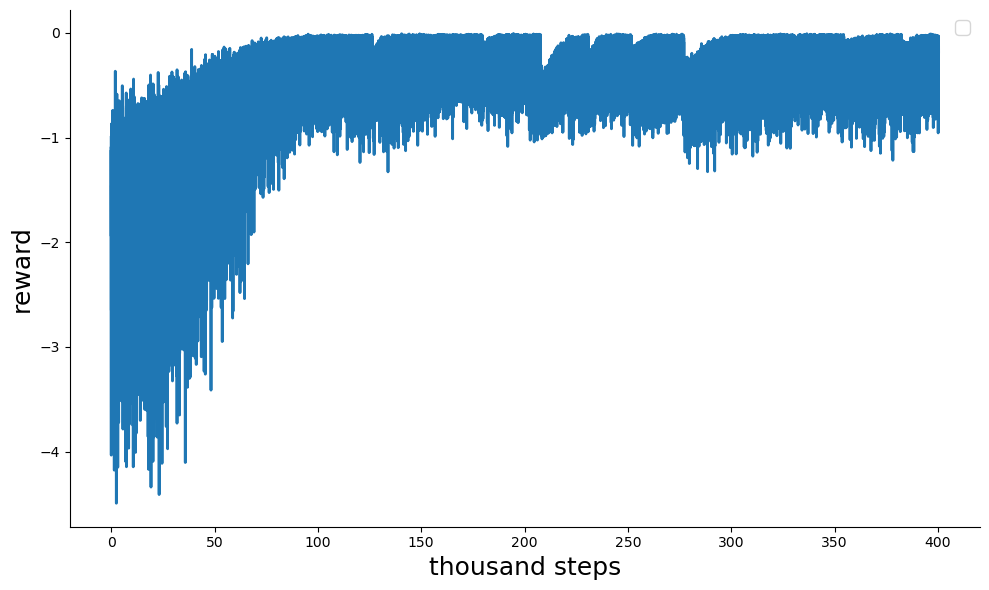

In [219]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_1.pdf", format="pdf")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


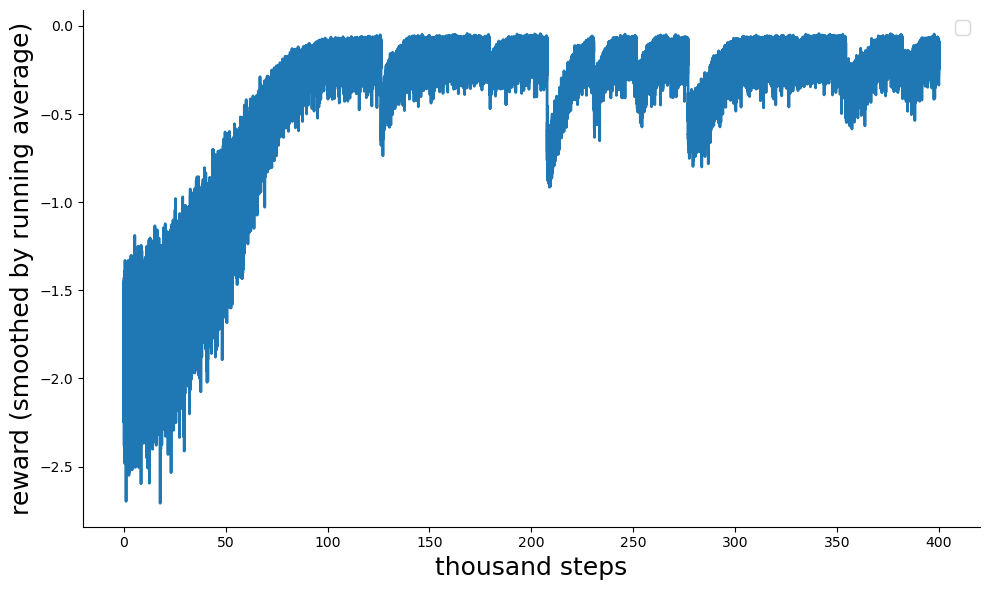

In [220]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))

# Apply running average (rolling mean) with a window size of 5
df["r_smoothed"] = df["r"].rolling(window=5).mean()

sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r_smoothed"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward (smoothed by running average)", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_2.pdf", format="pdf")
plt.show()

In [178]:
# Store actions in a list
actions = []

# Generate 1000 samples
for _ in range(100000):
    # Reset env with random hidden_state (as in your example)
    obs, info = env.reset()
    
    # Predict action
    action, _states = model.predict(obs, deterministic=False)  # deterministic=False for stochastic sampling
    actions.append(action)

KeyboardInterrupt: 

[0.38780558] 3.6235917
Reward at step 0: -0.07332060337066648
[0.32789934] 2.7536867
Reward at step 1: -0.01341435909271238
[0.29988387] 2.3903632
Reward at step 2: -0.014601105451583885
[0.3040629] 2.449544
Reward at step 3: -0.01042207479476931
[0.30454355] 2.4769769
Reward at step 4: -0.00994142293930056


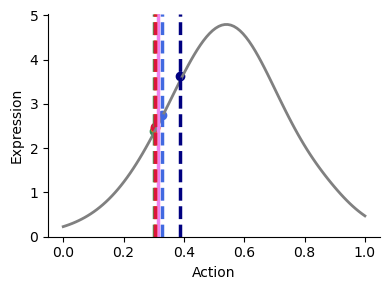

In [328]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(1)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[0]

# Plot reward landscape
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, 100), vals, label='Expression', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=2.5, label=f'Optimal')

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step])
    plt.scatter(action,obs[0,3*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Expression')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_1.pdf", format="pdf")
plt.show()


[0.38780558] 0.7299616
Reward at step 0: -0.07332060337066648
[0.32789934] 0.79760456
Reward at step 1: -0.01341435909271238
[0.29988387] 0.82224774
Reward at step 2: -0.014601105451583885
[0.3040629] 0.829926
Reward at step 3: -0.01042207479476931
[0.30454355] 0.8390099
Reward at step 4: -0.00994142293930056


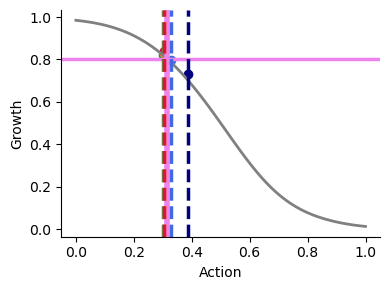

In [327]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(1)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]

# Plot reward landscape
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, 100), vals, label='Growth', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=4, label=f'Optimal')
plt.axhline(y=0.8, color="violet", linewidth=2.5, label=f'Desired minimal growth')

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step+1])
    plt.scatter(action,obs[0,3*step+1],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Growth')
# plt.title('Progression of Actions on the Reward Landscape')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_1_growth.pdf", format="pdf")
plt.show()


[0.38780558] 2.339
Reward at step 0: -0.10792829990386965
[0.4832456] 3.9907932
Reward at step 1: -0.012488269805908225
[0.4711131] 3.7292142
Reward at step 2: -0.024620795249938987
[0.47849828] 3.8989258
Reward at step 3: -0.017235600948333762
[0.482544] 3.9051445
Reward at step 4: -0.013189876079559348


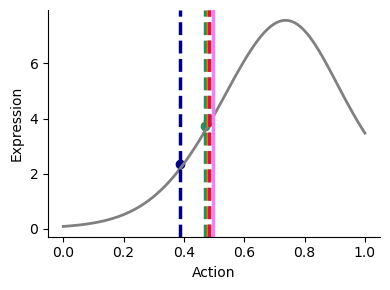

In [370]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(4)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[0]

# Plot reward landscape
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, 100), vals, label='Expression', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=2.5, label=f'Optimal')

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step])
    plt.scatter(action,obs[0,3*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Expression')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_2.pdf", format="pdf")
plt.show()


[0.38780558] 0.92808294
Reward at step 0: -0.10792829990386965
[0.4832456] 0.8496892
Reward at step 1: -0.012488269805908225
[0.4711131] 0.8380071
Reward at step 2: -0.024620795249938987
[0.47849828] 0.8195262
Reward at step 3: -0.017235600948333762
[0.482544] 0.83647275
Reward at step 4: -0.013189876079559348


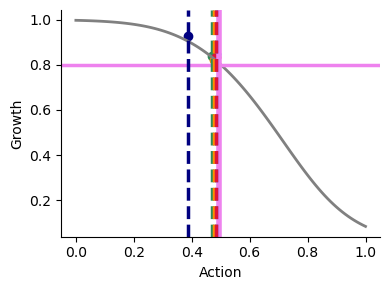

In [372]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(4)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]

# Plot reward landscape
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, 100), vals, label='Growth', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=4, label=f'Optimal')
plt.axhline(y=0.8, color="violet", linewidth=2.5, label=f'Desired minimal growth')

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step+1])
    plt.scatter(action,obs[0,3*step+1],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Growth')
# plt.title('Progression of Actions on the Reward Landscape')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_2_growth.pdf", format="pdf")
plt.show()


[0.38780558] 1.0747179
Reward at step 0: -0.23068621158599856
[0.56534827] 3.5787165
Reward at step 1: -0.053143525123596214
[0.5823017] 3.9841244
Reward at step 2: -0.03619011640548708
[0.58983004] 4.1275334
Reward at step 3: -0.02866175174713137
[0.59816617] 4.2461433
Reward at step 4: -0.020325624942779563


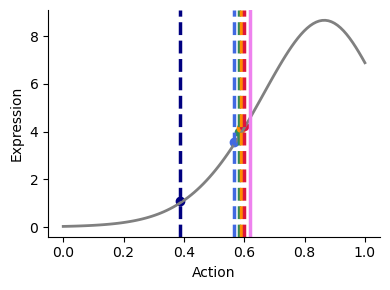

In [366]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(17)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[0]

# Plot reward landscape
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, 100), vals, label='Expression', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=2.5, label=f'Optimal')

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step])
    plt.scatter(action,obs[0,3*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Expression')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_3.pdf", format="pdf")
plt.show()


[0.38780558] 0.98901427
Reward at step 0: -0.23068621158599856
[0.56534827] 0.8627582
Reward at step 1: -0.053143525123596214
[0.5823017] 0.87618935
Reward at step 2: -0.03619011640548708
[0.58983004] 0.8646482
Reward at step 3: -0.02866175174713137
[0.59816617] 0.8451545
Reward at step 4: -0.020325624942779563


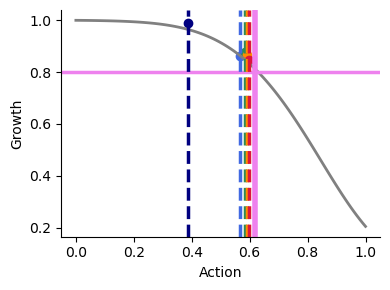

In [368]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(17)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]

# Plot reward landscape
plt.figure(figsize=(4, 3))
plt.plot(np.linspace(0, 1, 100), vals, label='Growth', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=4, label=f'Optimal')
plt.axhline(y=0.8, color="violet", linewidth=2.5, label=f'Desired minimal growth')

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step+1])
    plt.scatter(action,obs[0,3*step+1],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Growth')
# plt.title('Progression of Actions on the Reward Landscape')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_3_growth.pdf", format="pdf")
plt.show()


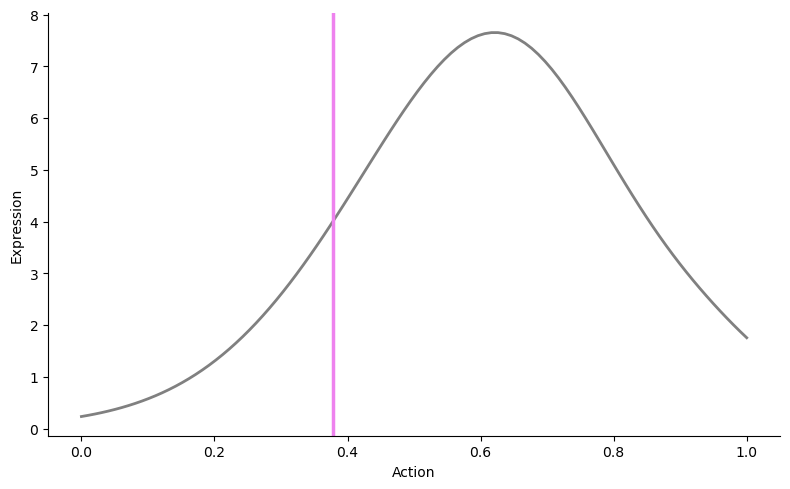

In [289]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(0)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[0]

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=2.5, label=f'Optimal')


# Labels and legend
plt.xlabel('Action')
plt.ylabel('Expression')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()

plt.savefig("expression.pdf", format="pdf")
plt.show()


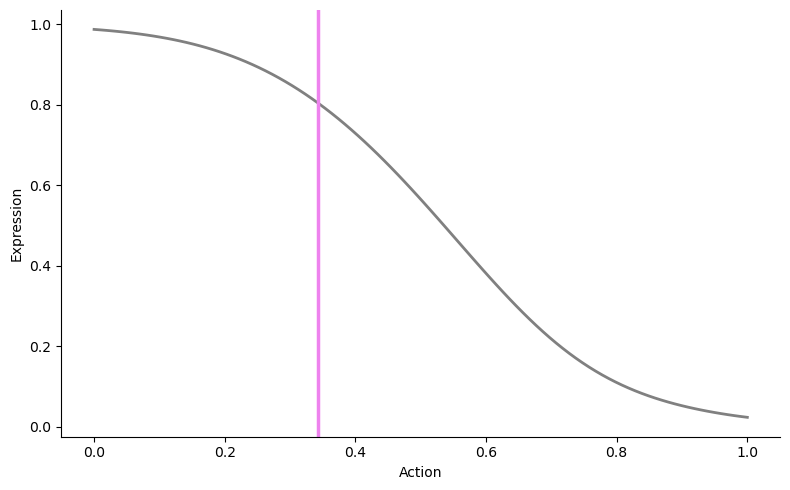

In [290]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(0)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=y_pred, color="violet", linewidth=2.5, label=f'Optimal')


# Labels and legend
plt.xlabel('Action')
plt.ylabel('Expression')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()

plt.savefig("growth.pdf", format="pdf")
plt.show()


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern


# --- Reward function wrapper ---
def reward_fn(x):
    # Ensure scalar conversion for Julia
    return float(jl.reward(float(x[0]), env.uncertain))

# --- Explicitly sample a random initial point ---
np.random.seed(1)
x0 = [np.random.uniform(0, 1)]           # 1 random initial action
y0 = [ -reward_fn([x0[0]]) ]             # corresponding negative reward (minimization)

print(f"Initial random point: x0={x0[0]:.3f}, y0={-y0[0]:.3f}")

# --- Run Bayesian Optimization with x0 and zero initial points ---
res = gp_minimize(
    func=lambda x: -reward_fn(x),          # minimize negative reward
    dimensions=[(0.0, 1.0)],               # action space
    n_calls=5,                             # total evaluations
    n_initial_points=0,                    # no random points generated internally
    x0=x0,
    y0=y0,
    random_state=42,
    base_estimator=GaussianProcessRegressor(kernel=Matern(nu=2.5))
)

# --- Compute reward landscape ---
x = np.linspace(0, 1, 200)
y = np.array(list(map(lambda xi: jl.reward(float(xi), env.uncertain), x)))

# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='gray', lw=2, label='Reward landscape')

# Color palette for GP-guided points
colors = plt.cm.plasma(np.linspace(0, 1, len(res.x_iters)-1))

# --- Plot first random point ---
plt.scatter(x0[0], -y0[0], color='red', s=100, edgecolor='k', marker='o', label='Initial random point')
plt.axvline(x=x0[0], color='red', linestyle='--', alpha=0.7)

# --- Plot GP-guided points ---
for i, (xi, yi, c) in enumerate(zip(res.x_iters[1:], res.func_vals[1:], colors)):
    plt.scatter(xi, -yi, color=c, s=80, edgecolor='k', label=f'GP step {i}')
    plt.axvline(x=xi, color=c, linestyle='--', alpha=0.6)

# --- Highlight optimum found ---
plt.scatter(res.x[0], -res.fun, color='black', s=120, marker='*', label='Optimum')

# --- Styling ---
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Bayesian Optimization on Reward Landscape (1 random + 4 GP-guided points)')
plt.legend(loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print final GP-guided points
for xi, yi in zip(res.x_iters, res.func_vals):
    print(f"x={xi[0]:.3f}, reward={-yi:.3f}")


TypeError: Julia: MethodError: no method matching reward(::Float64, ::PyArray{Float32, 1, true, true, Float32})
The function `reward` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  reward(::Any)
   @ Main ~/Coding/RL clean copy/models/model_host_cutoff.jl:495


In [293]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

first_growths = np.zeros(1000)
second_growths = np.zeros(1000)
third_growths = np.zeros(1000)
forth_growths = np.zeros(1000)
fifth_growths = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = reward
    first_growths[i] = obs[0,1]
    second_growths[i] = obs[0,4]
    third_growths[i] = obs[0,7]
    forth_growths[i] = obs[0,10]
    fifth_growths[i] = obs[0,13]



Text(0, 0.5, 'Reward')

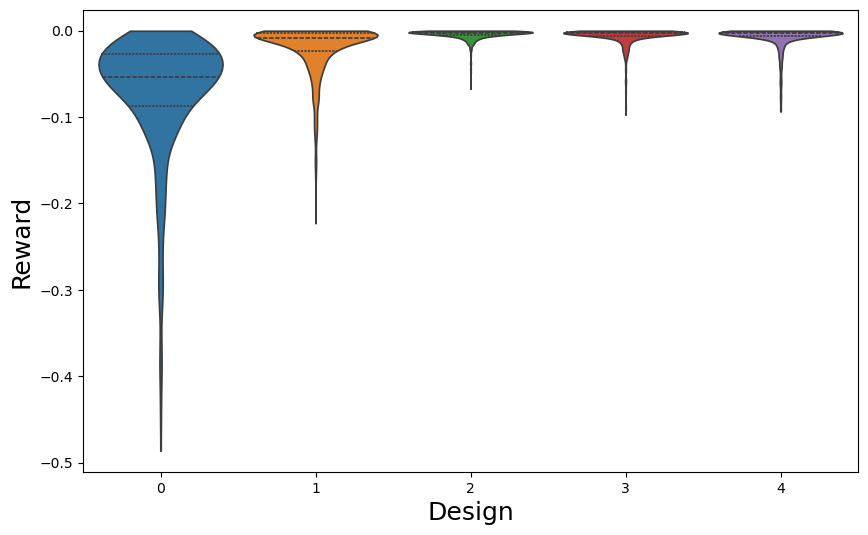

In [62]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile", cut = 0)
plt.xlabel("Step", fontsize=18)
plt.ylabel("Reward", fontsize=18)


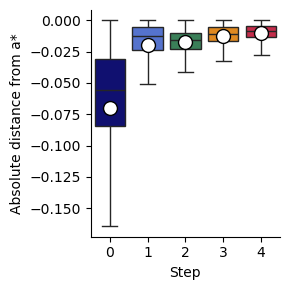

In [374]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']

plt.figure(figsize=(3, 3))
sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    showfliers=False,   # hides outliers
    showmeans=True,     # shows mean
    palette=colors,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":10}
)
plt.xlabel("Step")
plt.ylabel("Absolute distance from a*")
plt.tight_layout()
sns.despine()
plt.savefig("reward_boxplot.pdf", format="pdf")
plt.show()


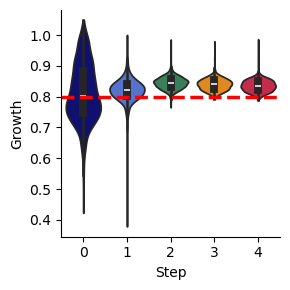

In [376]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
sns.violinplot(
    data=[first_growths, second_growths, third_growths, forth_growths, fifth_growths], palette=colors ,cut=0
)
plt.axhline(y=0.8, color="red", linestyle='--', linewidth=2.5, label=f'Desired minimal growth')
plt.xlabel("Step")
plt.ylabel("Growth")
plt.tight_layout()
sns.despine()
plt.savefig("growth_violinplot.pdf", format="pdf")
plt.show()


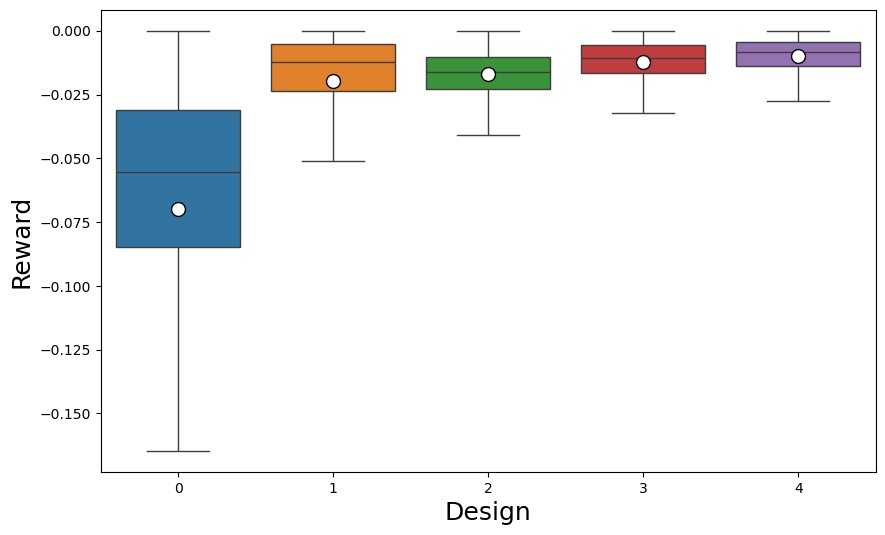

In [304]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    showfliers=False,   # hides outliers
    showmeans=True,     # shows mean
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":10}
)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.show()


In [29]:
import numpy as np
from skopt import gp_minimize
from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern

# Storage for environment rewards (regrets)
first_rewards = np.zeros(100)
second_rewards = np.zeros(100)
third_rewards = np.zeros(100)
forth_rewards = np.zeros(100)
fifth_rewards = np.zeros(100)

env.seed(31415)

# Run 100 independent BO trials
for i in range(100):
    obs, info = env.reset()

    # --- Define BO objective ---
    # For each candidate action, we take a real environment step
    # and return the *negative* observable used by BO.
    def reward_fn(x):
        # Take one environment step with this action
        obs_next, reward, terminated, truncated, info = env.step([x[0]])
        # Store actual reward in the correct slot
        step_idx = len(actions_so_far)
        if step_idx == 0:
            first_rewards[i] = reward
        elif step_idx == 1:
            second_rewards[i] = reward
        elif step_idx == 2:
            third_rewards[i] = reward
        elif step_idx == 3:
            forth_rewards[i] = reward
        elif step_idx == 4:
            fifth_rewards[i] = reward
        # Return the *proxy* observable (obs_next[0, 2*step]) for BO
        # but as a negative value since gp_minimize minimizes
        return -float(obs_next[0, 2 * step_idx])

    # --- Keep track of how many steps have been taken ---
    actions_so_far = []

    # --- Random initial point ---
    x0 = [np.random.uniform(0, 1)]
    actions_so_far.append(x0[0])

    # Evaluate initial point (this calls env.step)
    y0 = [reward_fn([x0[0]])]

    # --- Bayesian optimization using that starting point ---
    res = gp_minimize(
        func=reward_fn,
        dimensions=[(0.0, 1.0)],
        n_calls=5,                # total evaluations (1 random + 4 BO-guided)
        n_initial_points=0,       # we already supplied x0, y0
        x0=x0,
        y0=y0,
        random_state=42 + i,
        base_estimator=GaussianProcessRegressor(kernel=Matern(nu=2.5))
    )

# Done: first_rewards, second_rewards, ... now hold 100×5 actual environment rewards


KeyboardInterrupt: 

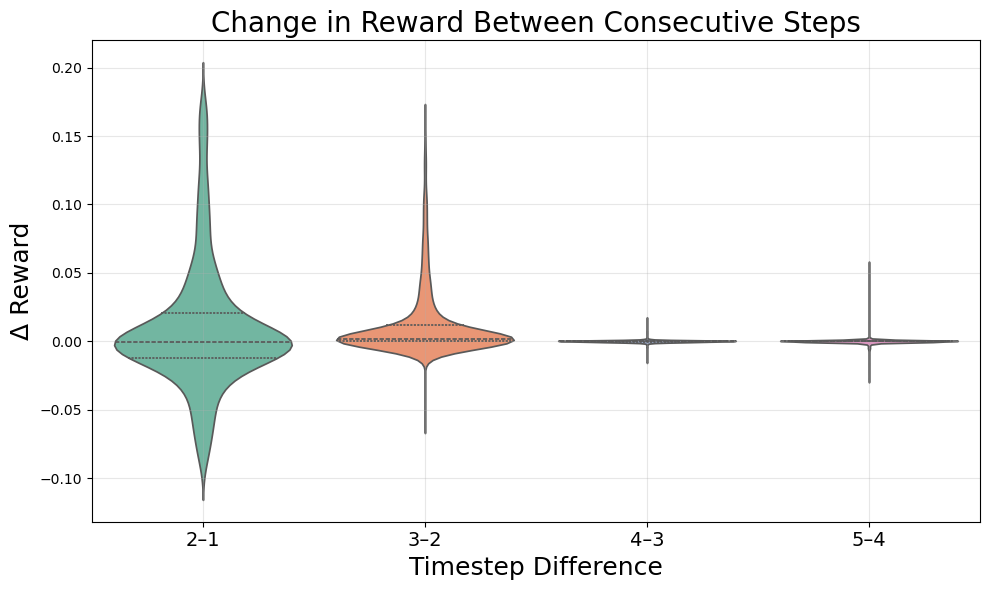

In [132]:
diff_2_1 = second_rewards - first_rewards
diff_3_2 = third_rewards - second_rewards
diff_4_3 = forth_rewards - third_rewards
diff_5_4 = fifth_rewards - forth_rewards

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=[diff_2_1, diff_3_2, diff_4_3, diff_5_4],
    inner="quartile",
    palette="Set2"
)

plt.xticks(
    ticks=np.arange(4),
    labels=["2–1", "3–2", "4–3", "5–4"],
    fontsize=14
)
plt.xlabel("Timestep Difference", fontsize=18)
plt.ylabel("Δ Reward", fontsize=18)
plt.title("Change in Reward Between Consecutive Steps", fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


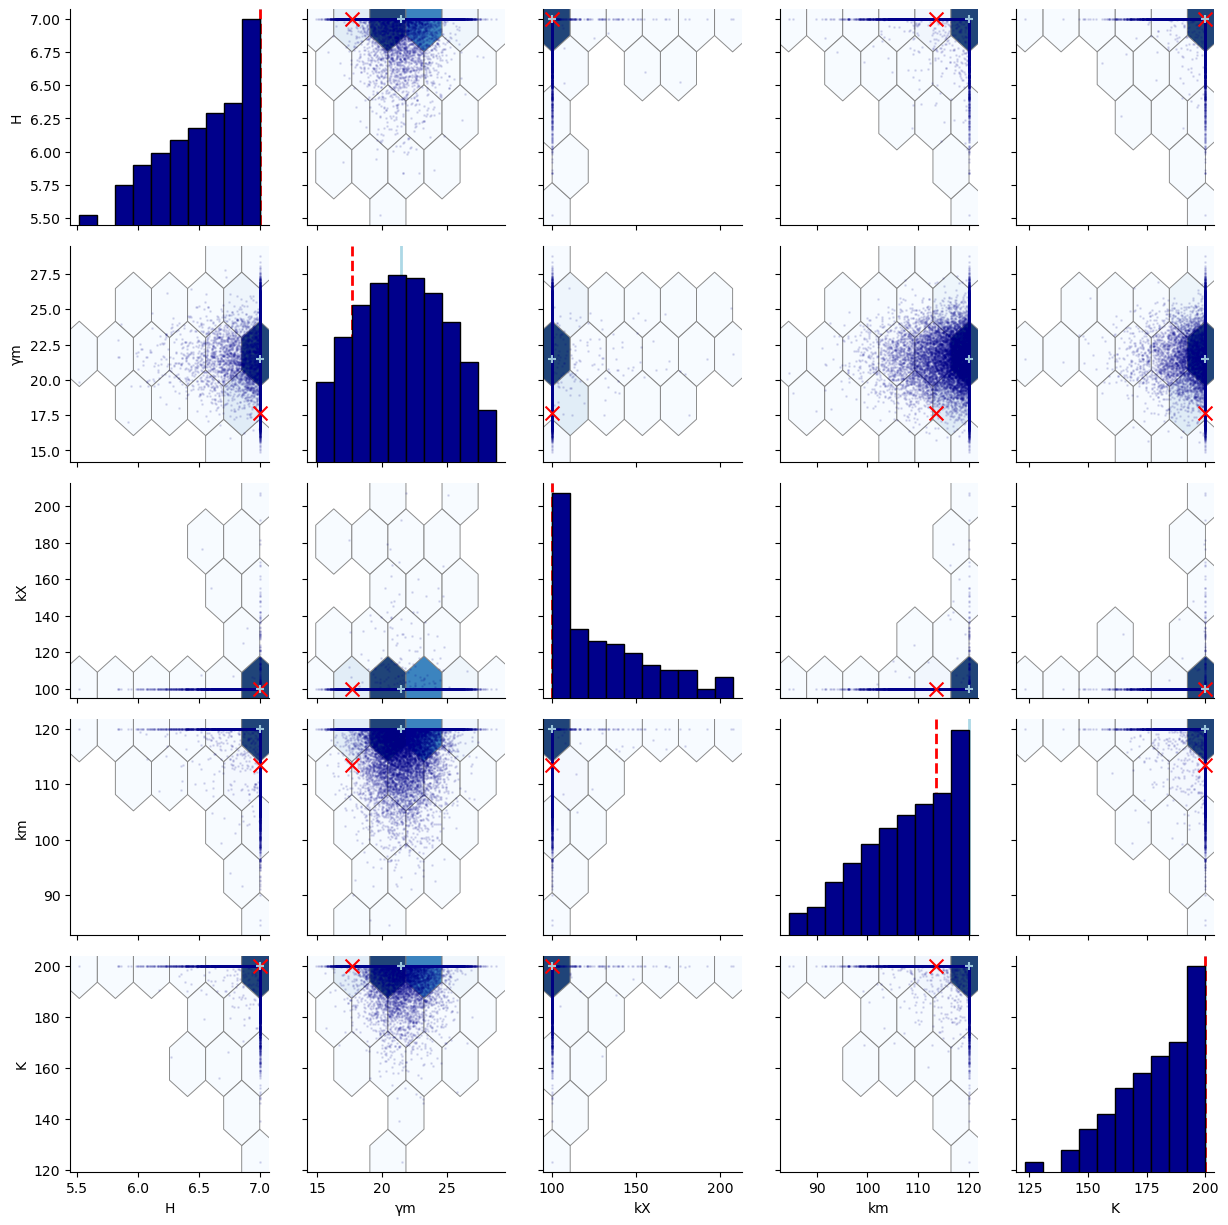

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the DataFrame
df = pd.DataFrame(actions, columns=["H", "γm", "kX", "km", "K"])

# Define ground truth and deterministic prediction
gt = [7.0, 17.6822, 100.0, 113.4372, 199.8989]
action_determinstic = model.predict(obs, deterministic=True)[0]
action_determinstic_denormalized = jl.denormalize_params(action_determinstic)

# Hexbin plot function
def hexbin_plot(x, y, color, **kwargs):
    ax = plt.gca()
    ax.hexbin(
        x, y,
        gridsize=5,
        cmap='Blues',
        mincnt=1,
        edgecolors='gray',
        linewidths=0.7,
        alpha=0.9
    )

# Histogram function for diagonal
def hist_plot(x, color, **kwargs):
    ax = plt.gca()
    ax.hist(x, bins=10, color='darkblue', edgecolor='black',log=True)

# Initialize PairGrid
g = sns.PairGrid(df)
g.map_lower(hexbin_plot)
g.map_diag(hist_plot)
g.map_upper(hexbin_plot)

# Overlay scatter points and vertical lines
for row in range(len(df.columns)):
    for col in range(len(df.columns)):
        ax = g.axes[row, col]

        if row == col:
            # Add vertical lines to diagonal
            ax.axvline(action_determinstic_denormalized[row], color='lightblue',zorder=10, linewidth=2, label='Deterministic' if row == 0 else "")
            ax.axvline(gt[row], color='red', linestyle='--', linewidth=2, zorder=10, label='Ground Truth' if row == 0 else "")
        else:
            ax.scatter(df.iloc[:, col], df.iloc[:, row],
                       color='darkblue', s=1, alpha=0.1, label='Samples' if (row, col) == (1, 0) else "")
            ax.scatter(gt[col], gt[row],
                       color='red', s=100,marker='x', label='Ground Truth' if (row, col) == (1, 0) else "")
            ax.scatter(action_determinstic_denormalized[col], action_determinstic_denormalized[row],
                       color='lightblue', marker="+", alpha=0.9, label='Deterministic' if (row, col) == (1, 0) else "")

# Add legend only once
handles, labels = g.axes[-1][0].get_legend_handles_labels()
if handles:
    g.axes[-1][0].legend(handles, labels, loc='upper right', fontsize='small')

plt.savefig("heatmap_1.pdf", format="pdf")

plt.show()


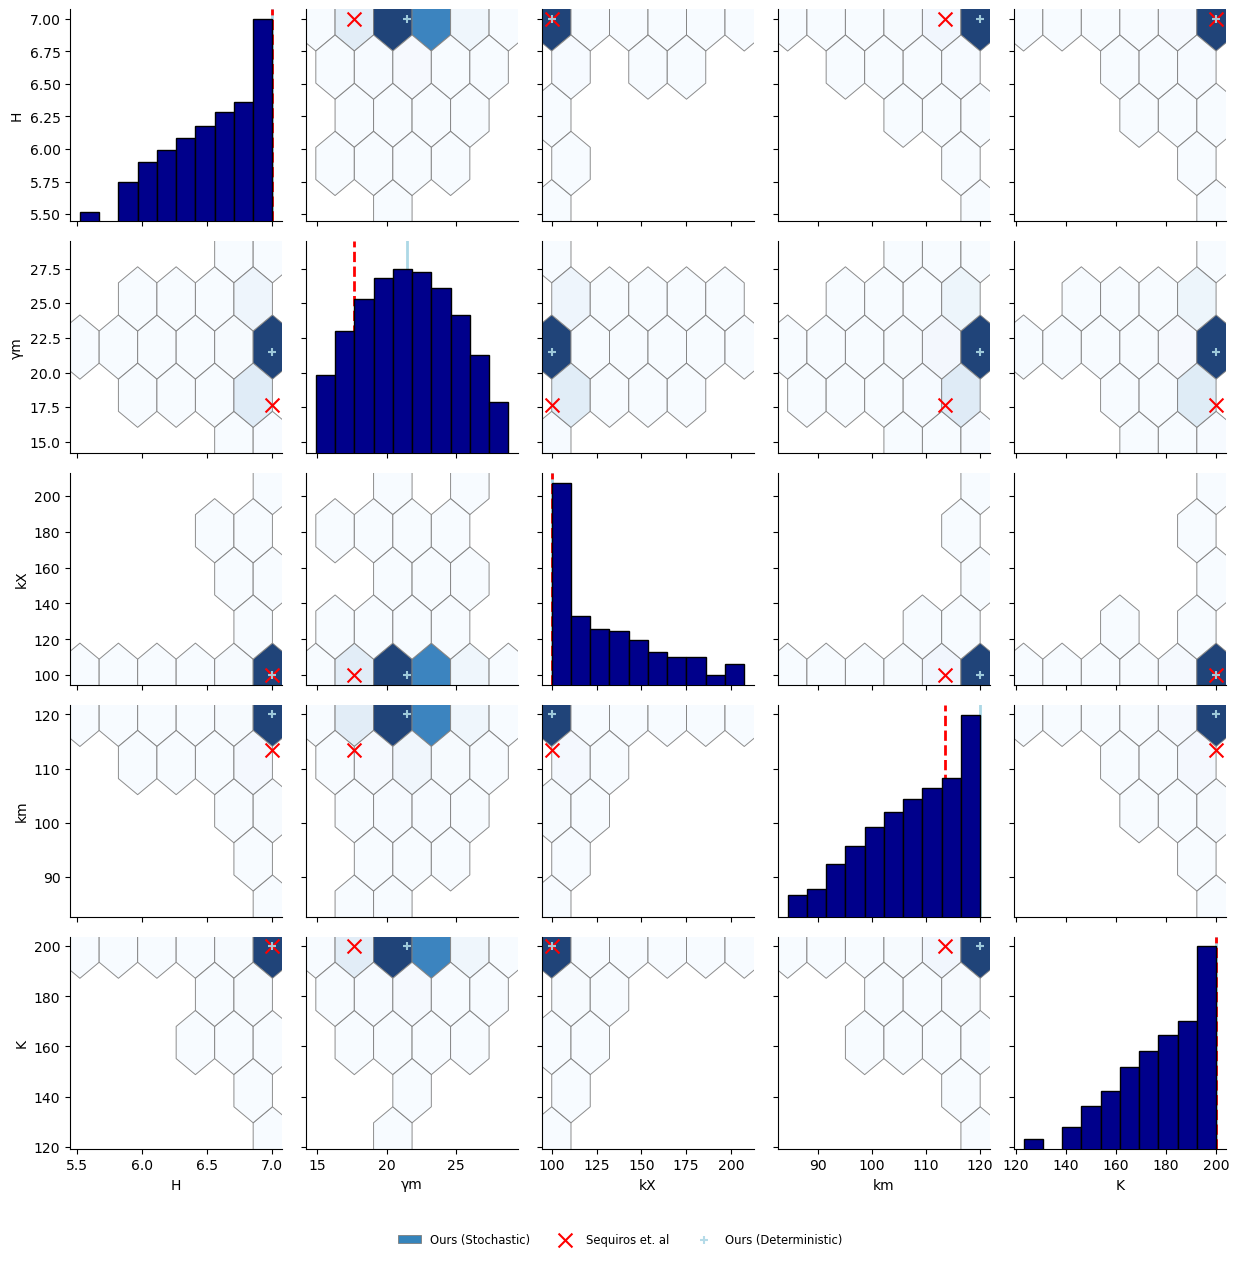

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the DataFrame
df = pd.DataFrame(actions, columns=["H", "γm", "kX", "km", "K"])

# Define ground truth and deterministic prediction
gt = [7.0, 17.6822, 100.0, 113.4372, 199.8989]
action_determinstic = model.predict(obs, deterministic=True)[0]
action_determinstic_denormalized = jl.denormalize_params(action_determinstic)

# Hexbin plot function
def hexbin_plot(x, y, color, **kwargs):
    ax = plt.gca()
    ax.hexbin(
        x, y,
        gridsize=5,
        cmap='Blues',
        mincnt=1,
        edgecolors='gray',
        linewidths=0.7,
        alpha=0.9,
        label = "Ours (Stochastic)"
    )

# Histogram function for diagonal
def hist_plot(x, color, **kwargs):
    ax = plt.gca()
    ax.hist(x, bins=10, color='darkblue', edgecolor='black',log=True)

# Initialize PairGrid
g = sns.PairGrid(df)
g.map_lower(hexbin_plot)
g.map_diag(hist_plot)
g.map_upper(hexbin_plot)

# Overlay scatter points and vertical lines
for row in range(len(df.columns)):
    for col in range(len(df.columns)):
        ax = g.axes[row, col]

        if row == col:
            # Add vertical lines to diagonal
            ax.axvline(action_determinstic_denormalized[row], color='lightblue',zorder=10, linewidth=2)
            ax.axvline(gt[row], color='red', linestyle='--', linewidth=2, zorder=10)
        else:
            # ax.scatter(df.iloc[:, col], df.iloc[:, row],
            #            color='darkblue', s=1, alpha=0.1, label='Samples' if (row, col) == (1, 0) else "")
            ax.scatter(gt[col], gt[row],
                       color='red', s=100,marker='x', label='Sequiros et. al' if (row, col) == (1, 0) else "")
            ax.scatter(action_determinstic_denormalized[col], action_determinstic_denormalized[row],
                       color='lightblue', marker="+", alpha=0.9, label='Ours (Deterministic)' if (row, col) == (1, 0) else "")
# Collect all handles and labels from axes
all_handles = []
all_labels = []

for ax_row in g.axes:
    for ax in ax_row:
        handles, labels = ax.get_legend_handles_labels()
        all_handles.extend(handles)
        all_labels.extend(labels)

# Remove duplicate labels while preserving order
unique = dict()
for h, l in zip(all_handles, all_labels):
    if l not in unique:
        unique[l] = h

# Add the legend to the bottom of the figure
g.fig.legend(
    handles=unique.values(),
    labels=unique.keys(),
    loc='lower center',
    ncol=3,
    fontsize='small',
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)  # You can tweak this to adjust spacing
)

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.03, 1, 1])


plt.savefig("heatmap_1.pdf", format="pdf")


In [18]:
TEST_SEED = 31415

env.seed(TEST_SEED)

stochastic_policy_result = []
for i in range(1000):
    env.reset()
    action = model.predict(obs)[0]
    stochastic_policy_result.append(env.step(action)[1])

env.seed(TEST_SEED)

deterministic_policy_result = []
for i in range(1000):
    env.reset()
    action = model.predict(obs, deterministic=True)[0]
    deterministic_policy_result.append(env.step(action)[1])

env.seed(TEST_SEED)

sequiros_result = []
for i in range(1000):
    env.reset()
    sequiros_result.append(env.step(jl.normalize_params(np.array(gt, dtype=np.float32)))[1])







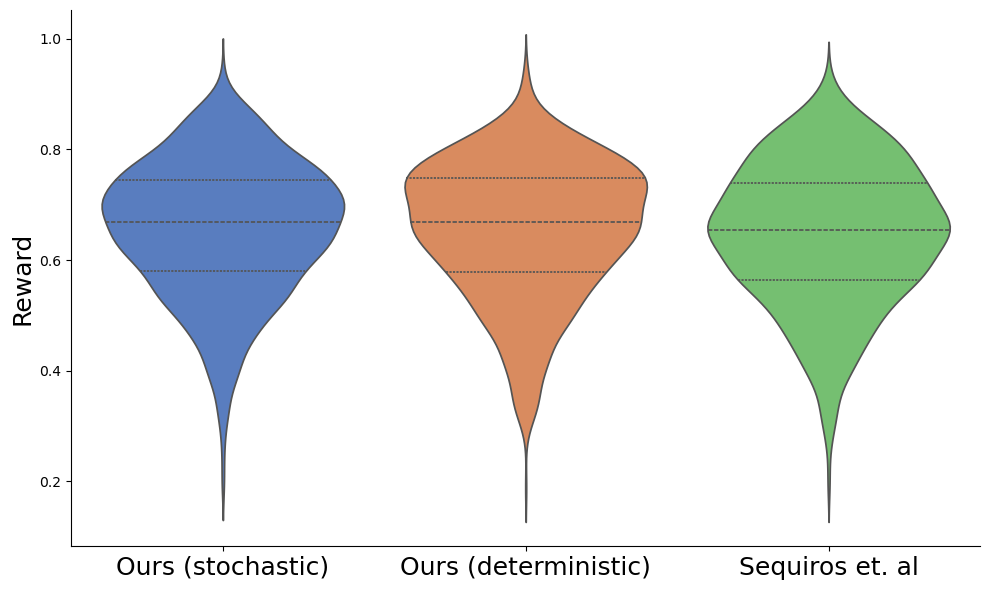

mean of policy_det_eval: 0.655084300093295
mean of policy_stoch_eval: 0.6573442237454391
mean of sequiros_eval: 0.6463913756595772


In [38]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=[stochastic_policy_result, deterministic_policy_result, sequiros_result], inner="quartile", palette="muted")
plt.xticks([0, 1, 2], ['Ours (stochastic)','Ours (deterministic)', 'Sequiros et. al'], fontsize=18)
plt.ylabel('Reward', fontsize=18)
sns.despine()
plt.tight_layout()
plt.savefig("violins_1.pdf", format="pdf")
plt.show()

print("mean of policy_det_eval:", np.mean(deterministic_policy_result))
print("mean of policy_stoch_eval:", np.mean(stochastic_policy_result))
print("mean of sequiros_eval:", np.mean(sequiros_result))

In [22]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(deterministic_policy_result, sequiros_result)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 1.553681749687165
P-value: 0.12041872361716038


In [16]:
stochastic_policy_result = []
for i in range(1000):
    action = model.predict(obs)[0]
    stochastic_policy_result.append(jl.reward(action))

action_determinstic = model.predict(obs, deterministic=True)[0]

policy_det_eval = jl.evaluate_params(action_determinstic)

sequiros_eval = jl.evaluate_params(jl.normalize_params(np.array(gt, dtype=np.float32)))



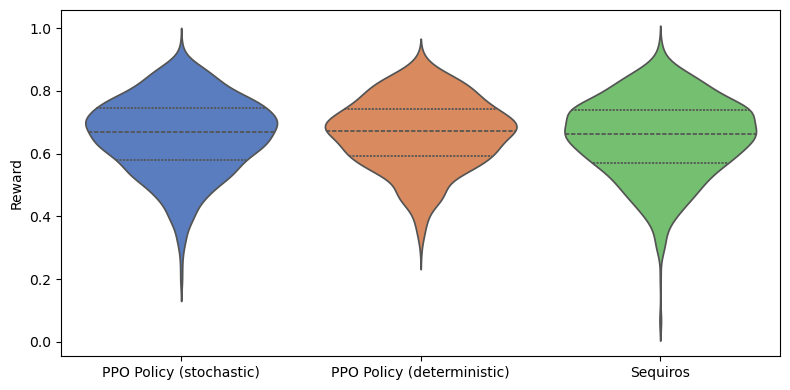

mean of policy_det_eval: 0.6635117965051814
mean of policy_stoch_eval: 0.6573442237454391
mean of sequiros_eval: 0.6493220805215304


In [42]:

plt.figure(figsize=(8, 4))
sns.violinplot(data=[stochastic_policy_result, policy_det_eval, sequiros_eval], inner="quartile", palette="muted")
plt.xticks([0, 1, 2], ['PPO Policy (stochastic)','PPO Policy (deterministic)', 'Sequiros'])
plt.ylabel('Reward')
plt.tight_layout()
plt.show()

print("mean of policy_det_eval:", np.mean(policy_det_eval))
print("mean of policy_stoch_eval:", np.mean(stochastic_policy_result))
print("mean of sequiros_eval:", np.mean(sequiros_eval))